In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('/mrhome/amingk/Documents/7TPD/ActStimRL')
from Madule import utils
from scipy.stats import gaussian_kde
import seaborn as sns
import matplotlib.pylab as plt

In [2]:
# Main directory of the subject
readMainDirec = '/mnt/projects/7TPD/bids/derivatives/fMRI_DA/AllBehData/'
# read clinical evaluation
clinical_evaluation = pd.read_csv(f'{readMainDirec}/clinical_evaluation.csv')
 

In [3]:
# PD clinical evaluation
clinical_evaluation_PD = clinical_evaluation[clinical_evaluation['group']=='PD']
most_affected = (clinical_evaluation_PD['most_affected_left_right_side_UPDRSON'] - clinical_evaluation_PD['most_affected_left_right_side_UPDRSOFF']).to_numpy()
UPDRS = (clinical_evaluation_PD['total_UPDRSON'] - clinical_evaluation_PD['total_UPDRSOFF']).to_numpy()

In [4]:
# model in PD
pickelDir_PD = f'/mnt/projects/7TPD/bids/derivatives/fMRI_DA/AllBehData/Behavioral_Modeling/Tabel3/PD/tabel3_model1_complement_prob_PD.pkl'
loadPkl_PD = utils.load_pickle(load_path=pickelDir_PD)
fit_PD = loadPkl_PD['fit']
  
# Extracting posterior distributions for each of four main unkhown parameters in PD
transfer_alpha_pos_PD = fit_PD["transfer_alpha_pos"] 
transfer_alpha_neg_PD = fit_PD["transfer_alpha_neg"] 
transfer_sensitivity_PD = fit_PD["transfer_sensitivity"] 
transfer_weight_PD = fit_PD["transfer_weight"]
 
# Estimate the density 
def get_mode_density(values):
    kde = gaussian_kde(values)
    x_grid = np.linspace(min(values), max(values), 1000)
    return x_grid[np.argmax(kde(x_grid))]
# dimetion of array
nParts= transfer_alpha_pos_PD.shape[0]
nMeds= transfer_alpha_pos_PD.shape[1]
nConds = 2
# Initialize array for modes
map_alpha_pos_PD = np.zeros((nParts, nMeds))
map_alpha_neg_PD = np.zeros((nParts, nMeds))
map_sensitivity_PD = np.zeros((nParts, nMeds))
for i in range(nParts):
    for j in range(nMeds):
        map_alpha_pos_PD[i,j] = get_mode_density(transfer_alpha_pos_PD[i,j]) 
        map_alpha_neg_PD[i,j] = get_mode_density(transfer_alpha_neg_PD[i,j]) 
        map_sensitivity_PD[i,j] = get_mode_density(transfer_sensitivity_PD[i,j]) 

# seighting parameters
map_weighting_PD = np.zeros((nParts, nConds, nMeds))
for i in range(nParts):
    for j in range(nConds):
        for k in range(nMeds):
            map_weighting_PD[i,j, k] = get_mode_density(transfer_weight_PD[i,j,k]) 


In [5]:
# differnce between On and OFF medication
map_med_alpha_pos_PD = map_alpha_pos_PD[:,1] - map_alpha_pos_PD[:,0]
map_med_alpha_neg_PD = map_alpha_neg_PD[:,1]- map_alpha_neg_PD[:,0]
map_med_sensitivity_PD = map_sensitivity_PD[:,1]- map_sensitivity_PD[:,0]
map_med_weighting_act_PD = map_weighting_PD[:,0, 1] - map_weighting_PD[:,0, 0]
map_med_weighting_clr_PD = map_weighting_PD[:,1, 1] - map_weighting_PD[:,1, 0]
map_med_weighting_PD = (map_weighting_PD[:,0, 1] - map_weighting_PD[:,0, 0]) - (map_weighting_PD[:,1, 1] - map_weighting_PD[:,1, 0])
map_mean_weighting_PD = (map_weighting_PD[:,0, 1] - map_weighting_PD[:,0, 0]) + (map_weighting_PD[:,1, 1] - map_weighting_PD[:,1, 0])

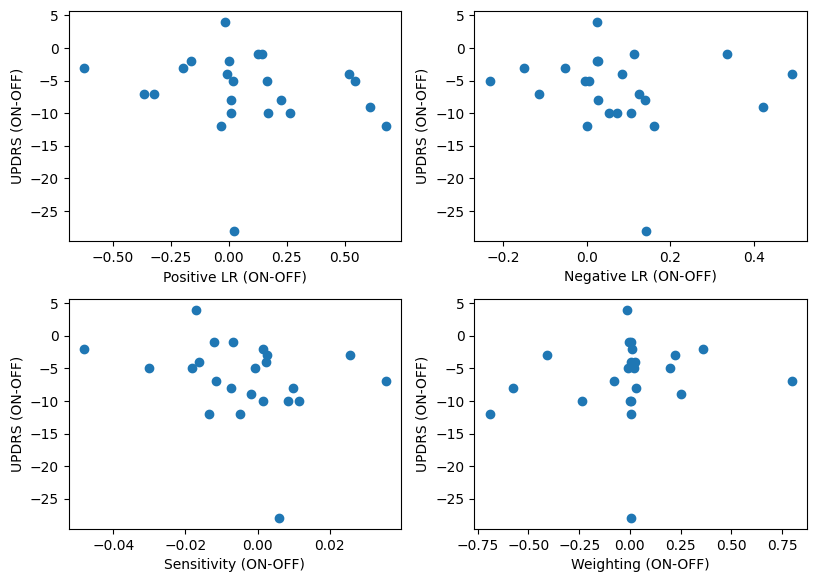

In [8]:
# ---------- Setup Figure----------
# Desired size in cm
width_cm = 21
height_cm = 15
# Convert to inches
width_in = width_cm / 2.54
height_in = height_cm / 2.54


fig, axs = plt.subplots(2, 2, figsize=(width_in, height_in))
axs = axs.flatten()

# poistive learning rate
axs[0].scatter(map_med_alpha_pos_PD, UPDRS)
axs[0].set_xlabel('Positive LR (ON-OFF)')
axs[0].set_ylabel('UPDRS (ON-OFF)')

# negative learning rate
axs[1].scatter(map_med_alpha_neg_PD, UPDRS)
axs[1].set_xlabel('Negative LR (ON-OFF)')
axs[1].set_ylabel('UPDRS (ON-OFF)')


# sensitivity 
axs[2].scatter(map_med_sensitivity_PD, UPDRS)
axs[2].set_xlabel('Sensitivity (ON-OFF)')
axs[2].set_ylabel('UPDRS (ON-OFF)')
 
# sensitivity 
axs[3].scatter(map_med_weighting_PD, UPDRS)
axs[3].set_xlabel('Weighting (ON-OFF)')
axs[3].set_ylabel('UPDRS (ON-OFF)')
 
# Layout
plt.tight_layout()

In [ ]:
np.mean([map_weighting_PD[:,0, 1],map_weighting_PD[:,0, 0], 1- map_weighting_PD[:,1, 1], 1-map_weighting_PD[:,1, 0]])

In [16]:
map_weighting_PD

array([ 3.66383089e-03, -5.24365912e-03,  1.65818107e-01,  1.27316334e-02,
       -5.73926381e-01,  7.01638974e-01,  1.17244329e-01, -2.76667900e-04,
       -5.93395931e-03, -3.58713138e-01, -1.45458785e-02,  4.16098503e-01,
       -1.89105321e-01,  2.38552197e-01, -2.28570602e-01,  3.58000179e-03,
        1.32479363e-02,  9.23509968e-03, -1.12980130e-02, -2.31930280e-01,
        1.53392247e-03,  3.86938428e-03, -2.66227256e-05])

In [12]:
map_med_alpha_neg_PD

array([ 0.10615491,  0.14308827, -0.11388362,  0.02435404,  0.1389073 ,
        0.00109458,  0.12459165,  0.16136731,  0.02690609,  0.02472865,
       -0.00367531, -0.05082702,  0.00542235,  0.05350417, -0.14960387,
        0.49030679,  0.08542884,  0.11380636,  0.02594226,  0.42246764,
        0.33535871, -0.23232243,  0.07255947])